## System Analyzer
A notebook (Maybe soon converted to a module) used for analyzing the system in the system.conf file

In [ ]:
import sys
sys.path.append('..')

from include import *
from analyzer_functions import *

In [2]:
# Defining system to work and all the paths to different files (Move to a config file later on)
sys_path = get_path(sub_path="1wave_9010")
rep_str = get_path(sub_path="output/rep2", main_path=sys_path)
rep_dir = get_path(sub_path=rep_str)
out_str = get_path(sub_path="output", main_path=sys_path)
out_dir = get_path(sub_path=out_str)
calm_dir = get_path(main_path=rep_dir, sub_path="CALM")

# Raw filenames
xtc = "fixed.xtc"
pdb = "fixed.pdb"
tpr = "fixed.tpr"
dim = "dimensions.csv"

# Select the indexes of upper and lower for all lipid components
selections = {
    "PO4_1": "resname CDL0 and name PO41",
    "PO4_2": "resname CDL0 and name PO42",
    "NC3": "resname POPC and name NC3"
}

# Loading the CALM analysis
dim_path = get_path(main_path=calm_dir, sub_path=dim)   # Loading the path to the dim.csv file
trj_idxs, boxsizes = load_CALM_dimensions(dim_path, calm_dir)

# Load the system using MDAnalysis
system = load_mda_universe(rep_dir, pdb, xtc)

# Splitting the system up into a lower and upper membrane using the leaflet.ndx file
leaflets = "leaflets.ndx"               # This contains the atoms selected for the upper and lower leaflet
                                        # The leaflets.ndx should contain all the atoms that should be mapped to curvature, 
                                        # i.e. NC3, PO41 and PO42 when working with a POPC, CDL0 system 
leaflets_ndx = load_leaflets_idx(out_dir, leaflets)

/home/danie/miniconda3/envs/Thesis_WSL/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


Loading Leaflets from: /home/danie/erda/1wave_9010/output/leaflets.ndx


## Obtaining the positions from a MDA selection

In [3]:
def select_groups(system, leaflets_ndx, selections):
    """Splits the system up into groups. Groups are the information on specific atoms, 
    and we can use logica operators on them to easier select positions later.
    ARGS:
        system: the MDAnalysis universe object containing the loaded system
        leaflets_ndx: the indexes of the upper and lower leaflet, as loaded from the leaflets.ndx file
        selections: a dictionary containing the selection strings for the different groups we want to track (Should be available in the system)"""
    
    # Adding the selection to a group dictionary
    keys = selections.keys()
    groups = {
        key: system.select_atoms(selections[key]) for key in keys
    }
    # Adding the upper and lower leaflet information    
    groups["Upper"] = system.atoms[leaflets_ndx["Upper"]]
    groups["Lower"] = system.atoms[leaflets_ndx["Lower"]]

    return groups

# generate the positions of all atoms for the specific frame
def get_positions(system, groups, selections, trj_idxs):
    """Generates the positions of all atoms for the specific frame, from a given selection.
    These are then grouped together in a dictionary"""
    keys = selections.keys()
    # Splitting up the groups into upper and lower leaflets
    groups_to_track = {         # A generator object for storing the selections of the two leaflets.
        f"{key}_{leaflet}": groups[key] & groups[leaflet]
        for key in keys
        for leaflet in ["Upper", "Lower"]
    }
    
    # Pre-allocating the data dictionary to store the positions of all groups for the selected trajectory indices.
    n_trjs = len(trj_idxs)
    data_raw = {name: np.zeros((n_trjs, len(groups_to_track[name]), 3), dtype=float) for name in groups_to_track}
    
    # Preallocate for averaged PO4 positions
    data_raw["CDL_Upper"] = np.zeros((n_trjs, len(groups_to_track["PO4_1_Upper"]), 3))
    data_raw["CDL_Lower"] = np.zeros((n_trjs, len(groups_to_track["PO4_1_Lower"]), 3))
    
    # Generate the positions for all groups
    for i, frame in enumerate(tqdm(trj_idxs)):
        system.trajectory[frame]   # Move to the specific frame in the trajectory
        
        for name, g in groups_to_track.items():
            data_raw[name][i] = g.positions
            
        # For each frame we calculate the mean between the two PO4 groups, since this is the best representation of the headgroup position
        pos_CDL_upper = np.mean([data_raw["PO4_1_Upper"][i], data_raw["PO4_2_Upper"][i]], axis=0)
        pos_CDL_lower = np.mean([data_raw["PO4_1_Lower"][i], data_raw["PO4_2_Lower"][i]], axis=0)
        data_raw["CDL_Upper"][i] = pos_CDL_upper
        data_raw["CDL_Lower"][i] = pos_CDL_lower
        
        
    # Output some information on the generated data
    print("Number of trjs analyzed:", n_trjs)
    print("Available groups and their number of atoms:")
    for name, group in data_raw.items():
        print(f"    {name}: {len(group[0])} atoms")
    return data_raw, groups_to_track         # Data is structured as: data[group_name][frame_idx][atom_idx][x/y/z] (Has been crosschecked in vmd)

groups = select_groups(system, leaflets_ndx, selections)
positions, groups_to_track = get_positions(system, groups, selections, trj_idxs)

  0%|          | 0/176 [00:00<?, ?it/s]

100%|██████████| 176/176 [00:18<00:00,  9.68it/s]

Number of trjs analyzed: 176
Available groups and their number of atoms:
    PO4_1_Upper: 53 atoms
    PO4_1_Lower: 53 atoms
    PO4_2_Upper: 53 atoms
    PO4_2_Lower: 53 atoms
    NC3_Upper: 479 atoms
    NC3_Lower: 479 atoms
    CDL_Upper: 53 atoms
    CDL_Lower: 53 atoms


## Mapping positions to curvature for each leaflet

In [4]:
# Load the information on the frames we analyze
n_frames = len(trj_idxs)
mean_curv_fnames = get_CALM_frame_names(calm_dir, filter="mean")
# Specify the keys for the curvature arrays
groups = ["NC3", "CDL"]
leaflets = ["Upper", "Lower"]

# Initialize curvature arrays
curvatures = {
    f"{g}_{l}": np.zeros(np.prod(np.shape(positions[f"{g}_{l}"])[:-1]))
    for g in groups
    for l in leaflets
}

for i in tqdm(range(n_frames)):
    # Load curvature maps
    curv_path = os.path.join(calm_dir, mean_curv_fnames[i])
    curv_data = load_npy(calm_dir, mean_curv_fnames[i], verbose=False)
    curv_map = {
        leaflets[0]: curv_data[0],
        leaflets[1]: curv_data[1],
    }

    for g in groups:
        for l in leaflets:
            pos = positions[f"{g}_{l}"][i]
            curv = pos_to_curvature(curv_map[l], pos, boxsizes[i])

            # Where are we allocating the values in the array
            n = len(pos)
            start = i * n
            end = (i + 1) * n

            curvatures[f"{g}_{l}"][start:end] = curv

# Information on the curvature arrays
for key in curvatures:
    print(f"{key}: {len(curvatures[key])} curvature values")

100%|██████████| 176/176 [00:35<00:00,  5.02it/s]

NC3_Upper: 84304 curvature values
NC3_Lower: 84304 curvature values
CDL_Upper: 9328 curvature values
CDL_Lower: 9328 curvature values


Text(0.5, 1.0, 'Middle')

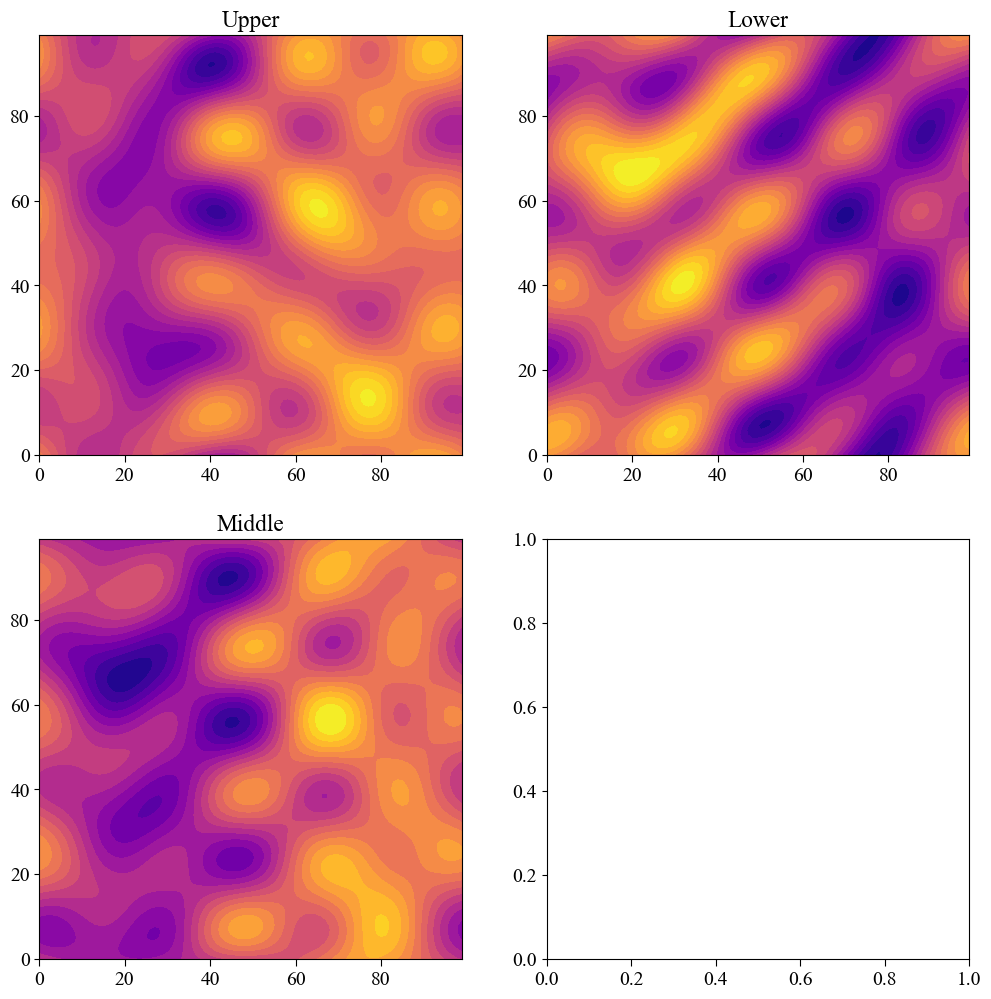

In [5]:
# Something about the mapping is wrong...
fig, ax = plt.subplots(2, 2, figsize=(12, 12))
ax = ax.flatten()
cmap = "plasma"
n_levels = 20
data = load_npy(calm_dir, mean_curv_fnames[0], verbose=False)
ax[0].contourf(data[0], levels=n_levels, cmap=cmap)
ax[0].set_title("Upper")

ax[1].contourf(data[1], levels=n_levels, cmap=cmap)
ax[1].set_title("Lower")
ax[2].contourf(data[2], levels=n_levels, cmap=cmap)
ax[2].set_title("Middle")

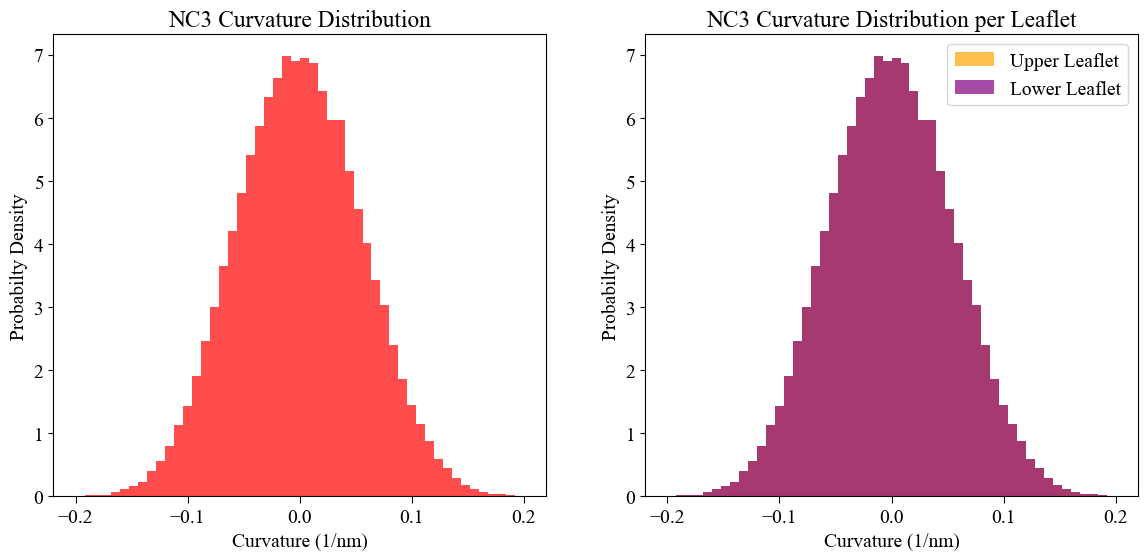

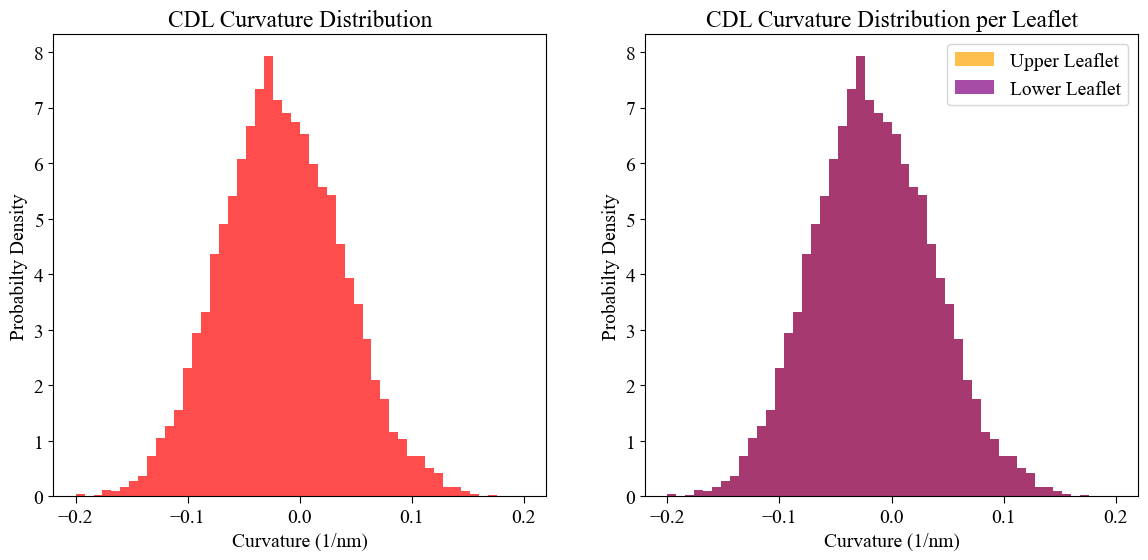

In [6]:
n_bins = 50
bin_range = (-0.2, 0.2)
groups = ["NC3", "CDL"]
leaflets = ["Upper", "Lower"]

for g in groups:
    for l in leaflets:
        upper = f"{g}_{l}"
        lower = f"{g}_{l}"
        
# Plotting the Curvature distribution fo the different species
    fig, ax = plt.subplots(1, 2, figsize=(14,6))
    curv_combined = np.concatenate([curvatures[upper], curvatures[lower]])

    ax[0].hist(curv_combined, bins=n_bins, range=bin_range, density=True, label="Both Leaflets", alpha=0.7, color="red");
    ax[1].hist(curvatures[upper], bins=n_bins, range=bin_range, density=True, label="Upper Leaflet", alpha=0.7, color="orange");
    ax[1].hist(curvatures[lower], bins=n_bins, range=bin_range, density=True, label="Lower Leaflet", alpha=0.7, color="purple");

    # Layout
    ax[0].set_title(f"{g} Curvature Distribution")
    ax[0].set_xlabel("Curvature (1/nm)")
    ax[0].set_ylabel("Probabilty Density")

    ax[1].set_title(f"{g} Curvature Distribution per Leaflet")
    ax[1].legend();
    ax[1].set_xlabel("Curvature (1/nm)")
    ax[1].set_ylabel("Probabilty Density")


According to Chat and Weria, we are currently plotting the lipids preffered curvature but are not accounting for the fact that the background distribution of lipids is not uniform, so more lipids are gathered in negative curvature. Therefore we need to remove the background by seeing the distribution of all lipids. This means normalizing in a sense:

$H(x,y) = \text{Mean Curvature}$

$$
P_{Lipid}(H) = \frac{N_{Lipid}(H)}{N_{\text{All Lipids}}(H)}
$$

But in order to understand if a Lipid is generally more observed in a specific curvature we divide the probability by the expected probability of observing a lipid of that type in our simulation (Which is simply the ratio of our system i.e. POPC = 0.9 and CDL = 0.1)
mathematically we would have:

$$
E_{Lipid}(H) = \frac{P_{Lipid}(H)}{\langle P_{Lipid}\rangle}
$$
This way if $E>1$ this means that there are more of this lipid than expected and $E<1$ means less than expected. For a specific case (CDL) this looks like:

$$
E_{CDL}(H) = \frac{N_{CDL}(H)}{N_{\text{All Lipids}}(H)} / \frac{N_{CDL}}{N_{All Lipids}}
$$




In [7]:
curvatures.keys()

### We combine all lipids in one background histogram
combined = np.concatenate([curvatures["NC3_Upper"], curvatures["NC3_Lower"], curvatures["CDL_Upper"], curvatures["CDL_Lower"]])
CDL_all = np.concatenate([curvatures["CDL_Upper"], curvatures["CDL_Lower"]])
POPC_combined = np.concatenate([curvatures["NC3_Upper"], curvatures["NC3_Lower"]])

n_bins = 40
bins = np.linspace(combined.min(), combined.max(), n_bins+1)

hist_all, _ = np.histogram(combined, bins=bins)
hist_CDL, _ = np.histogram(CDL_all, bins=bins)
hist_POPC, _ = np.histogram(POPC_combined, bins=bins)

# avoid division by zero
mask = hist_all > 0

P_CDL = np.zeros_like(hist_all, dtype=float)
P_CDL[mask] = hist_CDL[mask] / hist_all[mask]
# Bulk normalization to get the enrichment factor
bulk_CDL = len(CDL_all) / len(combined)

E_CDL = P_CDL / bulk_CDL

P_POPC = np.zeros_like(hist_all, dtype=float)
P_POPC[mask] = hist_POPC[mask] / hist_all[mask]
# Bulk normalization to get the enrichment factor
bulk_POPC = len(POPC_combined) / len(combined)
E_POPC = P_POPC / bulk_POPC

# compute bin centers
bin_centers = 0.5 * (bins[:-1] + bins[1:])

In [8]:
from stat_functions import *

# Calculating error propagation on two dependent variables (CDL and ALL) if CDL goes down this means that the total
# also goes down, so they are clearly dependent and the covariance should be accounted for
def Multivar_err_prop(deriv_vals, uncertainties):
    """Computes the error propagation for a multivariate function, given the derivative values and the uncertainties of the variables.
    ARGS:
        deriv_vals: a 2D array containing the derivative values for each variable and each data point (shape: n_variables x n_data_points)
        uncertainties: a 2D array containing the uncertainties for each variable and each data point (shape: n_variables x n_data_points)
        """
    # Compute the error propagation using the formula: sigma_f = sqrt( sum( (df/dx_i * sigma_x_i)^2 ) )
    squared_terms = (deriv_vals * uncertainties) ** 2    
    # Covariance term
    covariance_term = 2 * deriv_vals[0] * deriv_vals[1] * uncertainties[0] * uncertainties[1]
    # Summing the contributions together
    total_variance = np.sum(squared_terms, axis=0) + covariance_term      # Sums up the contributions from all variables for each data point

    return np.sqrt(total_variance)

# Creating the derivative values (We assume that if we use seperate POPC and CDL then they are maybe independent enough)
N_CDL, N_POPC = sp.symbols('x y')  # x = hist_CDL, y = hist_POPC
values = [hist_CDL, hist_POPC]   # Container for the values of the variables
uncertainties = np.array([np.sqrt(hist_CDL), np.sqrt(hist_POPC)])  # Uncertainties for each variable and each data point

# Calculating the error propagation values for the P_CDL and P_POPC
expr_CDL = N_CDL/(N_CDL+N_POPC)
deriv_expressions, deriv_vals_CDL, _ = get_derivatives(expr_CDL, [N_CDL, N_POPC], values=values)

expr_POPC = N_POPC/(N_CDL+N_POPC)
deriv_expressions, deriv_vals_POPC, _ = get_derivatives(expr_POPC, [N_CDL, N_POPC], values=values)

print("Derivatives (Expressions):", deriv_expressions)
print(f"Is value shape matching the number of data points? {np.array_equal(np.shape(deriv_vals_CDL), (2, n_bins))} - {np.shape(deriv_vals_CDL)}")

# Creating the error values with the formula for error propagation
P_CDL_err = Multivar_err_prop(deriv_vals_CDL, uncertainties=uncertainties)  # The uncertainties for each variable and each data point
P_POPC_err = Multivar_err_prop(deriv_vals_POPC, uncertainties=uncertainties)

# The error on the enrichment is simply the same error but scaled as there is no error on the bulk value
E_CDL_err = P_CDL_err / bulk_CDL
E_POPC_err = P_POPC_err / bulk_POPC


Derivatives (Expressions): [-y/(x + y)**2 -y/(x + y)**2 + 1/(x + y)]
Is value shape matching the number of data points? True - (2, 40)


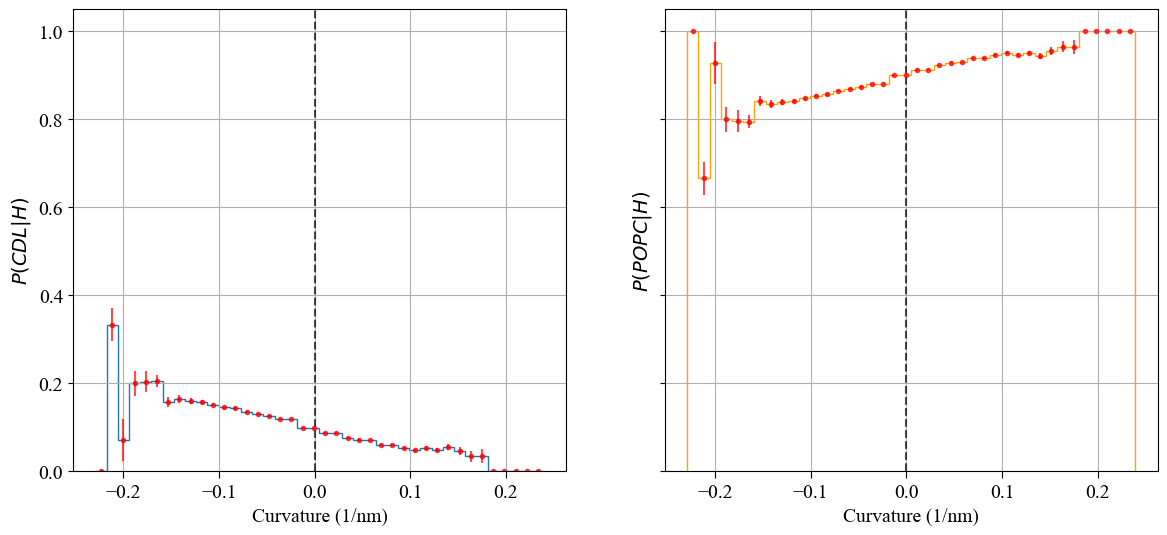

In [9]:
### Raw Plots ###
# Cardiolipin and POPC Curvature Preference (Probability of finding a lipid at a given curvature)
fig, ax = plt.subplots(1, 2, figsize=(14,6), sharex=True, sharey=True)
ax[0].stairs(P_CDL, bins, label="Cardiolipin")
ax[0].errorbar(bin_centers, P_CDL, yerr=P_CDL_err, fmt='.', color='red', alpha=0.7, label="Error")
ax[0].axvline(0, color='black', linestyle='--', alpha=0.7)

ax[1].stairs(P_POPC, bins, label="POPC", color="orange")
ax[1].errorbar(bin_centers, P_POPC, yerr=P_POPC_err, fmt='.', color='red', alpha=0.7, label="Error")
ax[1].axvline(0, color='black', linestyle='--', alpha=0.7)

# Layout
ax[0].set_xlabel("Curvature (1/nm)")
ax[0].set_ylabel("$P(CDL | H)$")
ax[1].set_xlabel("Curvature (1/nm)")
ax[1].set_ylabel("$P(POPC | H)$")
ax[0].grid()
ax[1].grid()

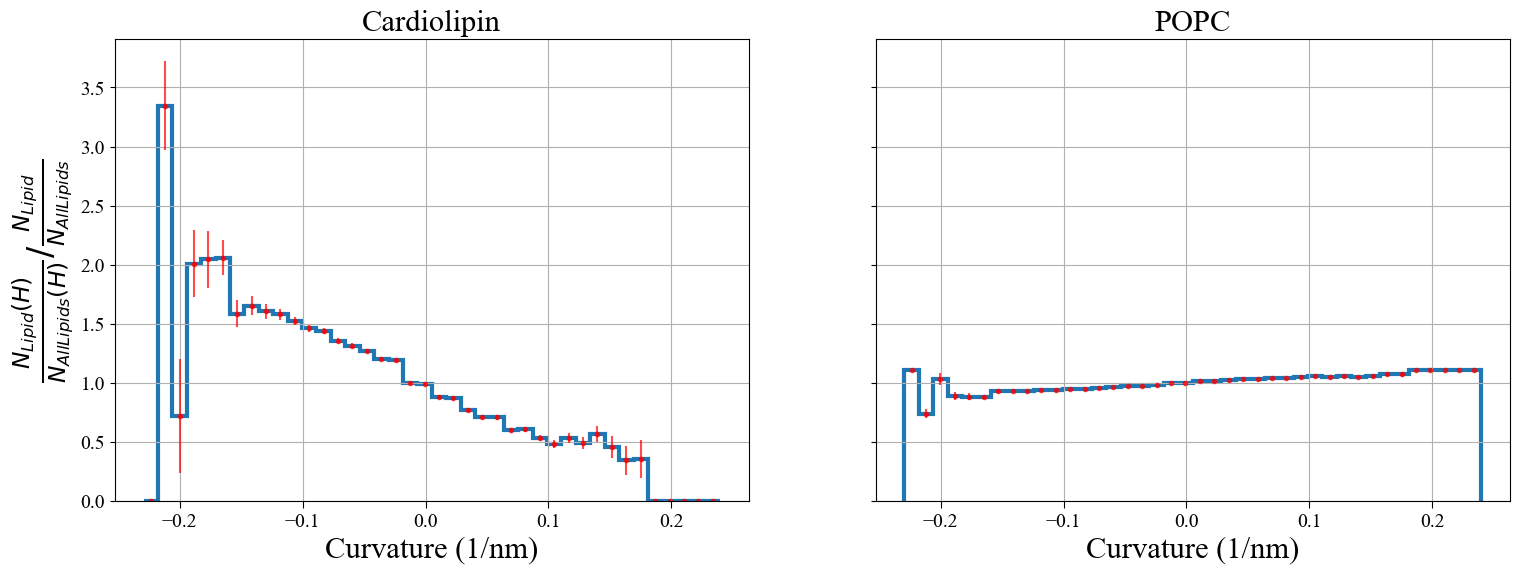

In [10]:
# Enrichment factor of CDL and POPC
fig, ax = plt.subplots(1, 2, figsize=(18,6), sharex=True, sharey=True)

# Plotting
ax[0].stairs(E_CDL, bins, label="Cardiolipin", lw=3)
ax[0].errorbar(bin_centers, E_CDL, yerr=E_CDL_err, fmt='.', color='r', alpha=0.7, label="Error")
ax[1].stairs(E_POPC, bins, label="POPC", lw=3)
ax[1].errorbar(bin_centers, E_POPC, yerr=E_POPC_err, fmt='.', color='r', alpha=0.7, label="Error")

# Layout
ax[0].set_xlabel("Curvature (1/nm)", fontsize=22)
ax[0].set_ylabel(r"$\frac{N_{Lipid}(H)}{N_{All Lipids}(H)} / \frac{N_{Lipid}}{N_{All Lipids}}$", fontsize=24)
ax[0].set_title("Cardiolipin", fontsize=22)
ax[1].set_xlabel("Curvature (1/nm)", fontsize=22)
ax[1].set_title("POPC", fontsize=22)
ax[0].grid()
ax[1].grid()


STAT ANALYSIS:
Chi2: 208.21
Reduced Chi2: 5.479
P-Value: 6.127599999999999e-46
Is fit good?  No

FIT PARAMS:
Curvature sensitivity (alpha): -7.7 ± 0.2
Baseline enrichment (b): 0.99 ± 0.01


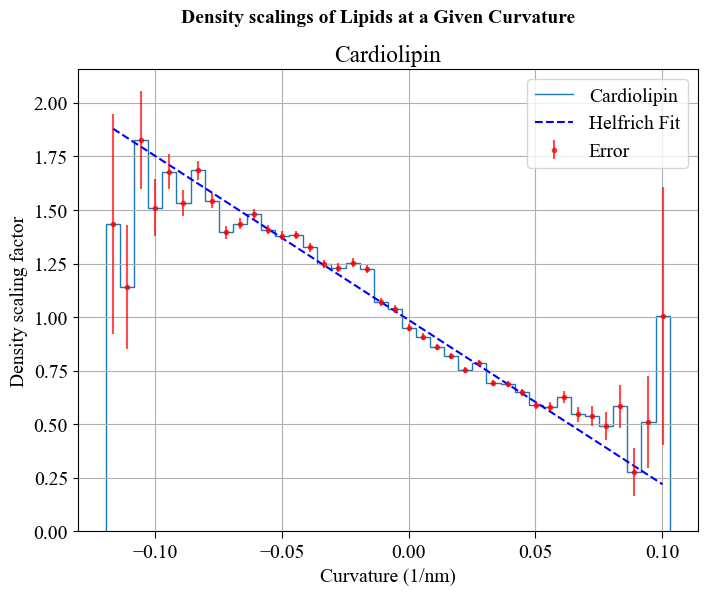

In [ ]:
# Fitting the enrichment to the Helfrich model


### Curve fitting ###
#What is a physically motivated model for this fit? This is what we should think about
def lin_func(x, alpha, b):
    return alpha * x + b

def fit_data(func, x_data, y_data, y_err):
    """Fits the data to a given function using curve_fit and returns the fit parameters and covariance."""
    # Fit data
    par, cov = curve_fit(func, x_data, y_data, sigma=y_err)
    
    # Create the fitted curve
    x_fit = x_data  # We can use the original x_data for plotting the fit, as it will be a straight line
    y_fit = func(x_fit, *par)
    return par, cov, x_fit, y_fit


data_x = bin_centers
data_y = E_CDL 
data_y_err = E_CDL_err 

# Fitting the Curvature Distribution of CDL
par, cov, x_fit, y_fit = fit_data(lin_func, data_x, data_y, data_y_err)

chi2, prop = get_chi2(data_y, y_fit, data_y_err, len(data_x)-2)
print("\nSTAT ANALYSIS:")
print("Chi2:", np.round(chi2, 2))
print("Reduced Chi2:", np.round(chi2/(len(data_x)-2), 3))
print("P-Value:", np.round(prop, 50))
print("Is fit good? ", "Yes" if prop > 0.05 else "No")

print("\nFIT PARAMS:")
print("Curvature sensitivity (alpha):", np.round(par[0], 1), "±", np.round(np.sqrt(cov[0][0]), 1))
print("Baseline enrichment (b):", np.round(par[1], 2), "±", np.round(np.sqrt(cov[1][1]), 2))


# Plotting
fig, ax = plt.subplots(figsize=(8,6))
ax.stairs(data_y, bins, label="Cardiolipin")
ax.plot(x_fit, y_fit, label="Helfrich Fit", color="blue", linestyle="--")
ax.errorbar(data_x, data_y, yerr=data_y_err, fmt='.', color='red', alpha=0.7, label="Error")
ax.legend()

# Layout
fig.suptitle("Density scalings of Lipids at a Given Curvature")
ax.set_xlabel("Curvature (1/nm)")
ax.set_ylabel("Density scaling factor")
ax.set_title("Cardiolipin")
ax.grid()


## Density of lipid types

In [ ]:
# Background density map
background_data = load_dat(rep_dir, "densmapBackground.dat", verbose=True) # Skip some of the data as this contains very large values???
boxsize = boxsizes[0] # The boxsize is the same for all

fig, ax = plt.subplots()
im = ax.imshow(background_data.T, origin="lower", extent=(0, boxsize[0], 0, boxsize[1]), aspect="auto", cmap="Reds")#, norm=norm)
# Other layout
fig.colorbar(im, ax=ax, label="Counts")
ax.set_xlabel("X (nm)")
ax.set_ylabel("Y (nm)")
ax.set_title("Background density");

Loading Data from: /home/danie/erda/1wave_9010/output/rep2/densmapBackground.dat


FileNotFoundError: /home/danie/erda/1wave_9010/output/rep2/densmapBackground.dat not found.

While this density map isn't useful to us directly as we can't make any solid conclusions about the distribution of lipids we can see a vague color difference between curvature regions but this is not a sign of curvature preference as this is in the background. This indicates that the local density of lipids in general are tighter in the negative curved regions.

Therefore we can similarly find the enrichment factor. A number telling how much more likely we are to find lipids in the bin compared to what is expected. i.e. $E=2$ means that if we expect a distribution of 10% CDL we could imagine 20% instead here.

In [11]:
# Background density map
background_data = load_dat(rep_dir, "densmapBackground.dat", verbose=True) # Skip some of the data as this contains very large values???

fnames = ["densmapCDL.dat", "densmapPOPC.dat"]
titles = ["CDL Headgroup (PO41 & PO42)", "POPC Headgroup (NC3)"]
lipid_names = ["CDL", "POPC"]
fractions = [0.1, 0.9] # These are the fractions of CDL and POPC in the system, which we will use to calculate the enrichment factor
threshold = 4000  # The threshold for which bins to use plot. Bins with fewer data points are not statistical reliable and will be set to 0

fig, ax = plt.subplots(1, 2, figsize=(18, 8))
ax = ax.flatten()
for i, fname in enumerate(fnames):
    # Load and plot data
    data = load_dat(rep_dir, fname, verbose=True)
    
    # Mask out the bins with too little data
    mask = background_data > threshold
    E = np.zeros_like(data)
    
    # Calculate the enrichment, which is how much more likely we are to find the specific lipid relative to the expected amount
    E[mask] = (data[mask] / background_data[mask]) / fractions[i]
    E[~mask] = 0

    # Plotting
    im = ax[i].imshow(E.T[5:-5, 5:-5], origin="lower", extent=(0, boxsize[0], 0, boxsize[1]), aspect="auto", cmap="Reds")#, norm=norm)
    # Other layout
    cbar = fig.colorbar(im, ax=ax[i])
    cbar.set_label(r"$\frac{N_{" + lipid_names[i] + r"}(x,y)}{N_{All Lipids}(x,y)} / \frac{N_{"+lipid_names[i]+"}}{N_{All Lipids}}$", fontsize=20)
    ax[i].set_xlabel("X (Å)", fontsize=22)
    if i == 0:
        ax[i].set_ylabel("Y (Å)", fontsize=22)
    ax[i].set_title(titles[i], fontsize=22)
fig.suptitle("Enrichment of lipids", fontsize=18);

Loading Data from: /home/danie/erda/1wave_9010/output/rep2/densmapBackground.dat


FileNotFoundError: /home/danie/erda/1wave_9010/output/rep2/densmapBackground.dat not found.

This also isn't a good representation of the curvature preference of lipids. This is a plot over the distribution of compared to the background, meaning we are taking into account the tighter packing of negatively curved regions, but we are not quantifying it in any way and actually seeing how much is changing dependent on curvature. 

While the enrichment factor does tell us that it is more likely, we have a hard time of quantifying it as we don't know how much is due to low statistics